### IMPORT LIBRARY

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer, KNNImputer
import warnings
warnings.filterwarnings('ignore')

### LOAD DATASET

In [79]:
df_train = pd.read_csv('Training_CKD_dataset.csv')
df_test = pd.read_csv('Testing_CKD_dataset.csv')
df_train.head()

,Target,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,...,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein,Diabetes,Hypertension,Smoking_Status,Family_History_Kidney
0,Healthy Kidney,29,1,28,97,69,99,0,12,95,...,96,7.547874,204,120,4,7.091259,Yes,Yes,Yes,Yes
1,Severe CKD (Stage 4),43,0,18,165,100,67,5,87,28,...,88,7.287338,166,277,2,7.875167,Yes,Yes,Yes,No
2,Healthy Kidney,77,0,32,116,63,101,0,16,100,...,82,9.114854,246,299,4,7.083558,No,No,Yes,No
3,Healthy Kidney,83,0,24,93,75,87,0,10,101,...,82,7.286450,173,285,4,6.428780,Yes,No,No,Yes
4,Healthy Kidney,38,1,19,111,70,92,0,10,102,...,106,8.376492,266,294,4,7.852894,Yes,No,Yes,No


In [80]:
df_train.shape
df_test.shape

(4800, 36)

In [81]:
df_train.isnull().sum()

Target                      0
Age                         0
Gender                      0
BMI                         0
Systolic_BP                 0
Diastolic_BP                0
Heart_Rate                  0
Serum_Creatinine            0
Blood_Urea_Nitrogen         0
eGFR                        0
Urine_Albumin               0
Urine_Protein               0
Albumin_Creatinine_Ratio    0
Urine_Specific_Gravity      0
Sodium                      0
Potassium                   0
Calcium                     0
Phosphorus                  0
Chloride                    0
Bicarbonate                 0
Hemoglobin                  0
RBC_Count                   0
WBC_Count                   0
Platelet_Count              0
Packed_Cell_Volume          0
Blood_Glucose_Random        0
Fasting_Glucose             0
HbA1c                       0
Cholesterol                 0
Triglycerides               0
Serum_Albumin               0
Total_Protein               0
Diabetes                    0
Hypertensi

In [82]:
df_test.isnull().sum()

Target                      0
Age                         0
Gender                      0
BMI                         0
Systolic_BP                 0
Diastolic_BP                0
Heart_Rate                  0
Serum_Creatinine            0
Blood_Urea_Nitrogen         0
eGFR                        0
Urine_Albumin               0
Urine_Protein               0
Albumin_Creatinine_Ratio    0
Urine_Specific_Gravity      0
Sodium                      0
Potassium                   0
Calcium                     0
Phosphorus                  0
Chloride                    0
Bicarbonate                 0
Hemoglobin                  0
RBC_Count                   0
WBC_Count                   0
Platelet_Count              0
Packed_Cell_Volume          0
Blood_Glucose_Random        0
Fasting_Glucose             0
HbA1c                       0
Cholesterol                 0
Triglycerides               0
Serum_Albumin               0
Total_Protein               0
Diabetes                    0
Hypertensi

In [83]:
df_train.columns

Index(['Target', 'Age', 'Gender', 'BMI', 'Systolic_BP', 'Diastolic_BP',
       'Heart_Rate', 'Serum_Creatinine', 'Blood_Urea_Nitrogen', 'eGFR',
       'Urine_Albumin', 'Urine_Protein', 'Albumin_Creatinine_Ratio',
       'Urine_Specific_Gravity', 'Sodium', 'Potassium', 'Calcium',
       'Phosphorus', 'Chloride', 'Bicarbonate', 'Hemoglobin', 'RBC_Count',
       'WBC_Count', 'Platelet_Count', 'Packed_Cell_Volume',
       'Blood_Glucose_Random', 'Fasting_Glucose', 'HbA1c', 'Cholesterol',
       'Triglycerides', 'Serum_Albumin', 'Total_Protein', 'Diabetes',
       'Hypertension', 'Smoking_Status', 'Family_History_Kidney'],
      dtype='object')

In [84]:
df_train['Target'].unique()

array(['Healthy Kidney', 'Severe CKD (Stage 4)', 'Mild CKD (Stage 1–2)',
       'Moderate CKD (Stage 3)', 'Kidney Failure (Stage 5)'], dtype=object)

In [85]:
df_train['Target'].value_counts()

Target
Healthy Kidney              15744
Mild CKD (Stage 1–2)         2491
Moderate CKD (Stage 3)       1489
Severe CKD (Stage 4)          856
Kidney Failure (Stage 5)      420
Name: count, dtype: int64

### EXPLORATORY DATA ANALYSIS

In [86]:
target_mapping = {
    'Healthy Kidney': 0,
    'Mild CKD (Stage 1–2)': 1,
    'Moderate CKD (Stage 3)': 2,
    'Severe CKD (Stage 4)': 3,
    'Kidney Failure (Stage 5)': 4
}

df_train['Target_encoded'] = df_train['Target'].map(target_mapping)
df_test['Target_encoded']  = df_test['Target'].map(target_mapping)

In [87]:
df_train = df_train.drop(columns=['Target'])
df_test = df_test.drop(columns=['Target'])

In [88]:
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3250',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'sans-serif',
    'font.size':        11,
})
 
PALETTE = ['#58a6ff', '#3fb950', '#f78166', '#d2a8ff', '#ffa657']
ACCENT  = '#f78166'


  [TRAIN]
   Stadium    0 | 15,744 ( 75.0%) █████████████████████████████████████
   Stadium    1 | 2,491 ( 11.9%) █████
   Stadium    2 | 1,489 (  7.1%) ███
   Stadium    3 |   856 (  4.1%) ██
   Stadium    4 |   420 (  2.0%) █

  [TEST]
   Stadium    0 | 3,615 ( 75.3%) █████████████████████████████████████
   Stadium    1 |   575 ( 12.0%) █████
   Stadium    2 |   318 (  6.6%) ███
   Stadium    3 |   196 (  4.1%) ██
   Stadium    4 |    96 (  2.0%) █


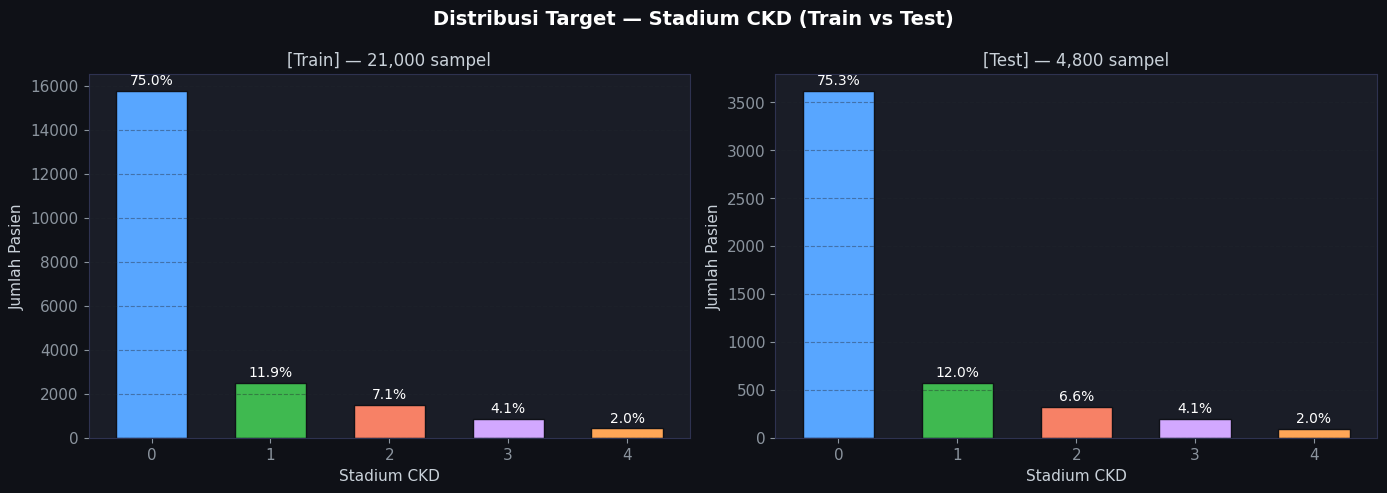

In [93]:
def print_target_dist(series, label):
    counts = series.value_counts().sort_index()
    pcts   = series.value_counts(normalize=True).sort_index() * 100
    print(f"\n  [{label}]")
    for cls, cnt, pct in zip(counts.index, counts.values, pcts.values):
        bar = "█" * int(pct / 2)
        print(f"   Stadium {cls:>4} | {cnt:>5,} ({pct:5.1f}%) {bar}")
 
print_target_dist(df_train['Target_encoded'], "TRAIN")
print_target_dist(df_test['Target_encoded'],  "TEST")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribusi Target — Stadium CKD (Train vs Test)",
             fontsize=14, fontweight='bold', color='white')
 
for ax, df_, label in zip(axes, [df_train, df_test], ['Train', 'Test']):
    counts = df_['Target_encoded'].value_counts().sort_index()
    pcts   = df_['Target_encoded'].value_counts(normalize=True).sort_index() * 100
    bars   = ax.bar(counts.index.astype(str), counts.values,
                    color=PALETTE[:len(counts)], edgecolor='#0f1117', width=0.6)
    for bar, pct in zip(bars, pcts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + counts.max() * 0.01,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, color='white')
    ax.set_title(f"[{label}] — {len(df_):,} sampel", fontsize=12)
    ax.set_xlabel("Stadium CKD")
    ax.set_ylabel("Jumlah Pasien")
    ax.grid(axis='y', alpha=0.4)
 
plt.tight_layout()
plt.savefig("01_target_distribution.png", dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

In [94]:
df_train

,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,Urine_Albumin,...,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein,Diabetes,Hypertension,Smoking_Status,Family_History_Kidney,Target_encoded
0,29,1,28,97,69,99,0,12,95,6,...,7.547874,204,120,4,7.091259,Yes,Yes,Yes,Yes,0
1,43,0,18,165,100,67,5,87,28,318,...,7.287338,166,277,2,7.875167,Yes,Yes,Yes,No,3
2,77,0,32,116,63,101,0,16,100,1,...,9.114854,246,299,4,7.083558,No,No,Yes,No,0
3,83,0,24,93,75,87,0,10,101,11,...,7.286450,173,285,4,6.428780,Yes,No,No,Yes,0
4,38,1,19,111,70,92,0,10,102,9,...,8.376492,266,294,4,7.852894,Yes,No,Yes,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20995,45,0,19,98,62,86,0,11,115,14,...,6.337256,255,275,4,6.536640,No,No,No,No,0
20996,82,0,20,125,81,88,1,24,70,44,...,4.149633,207,297,3,6.707196,Yes,Yes,Yes,No,1
20997,65,0,23,119,62,95,0,19,105,16,...,5.738345,249,196,4,6.576637,Yes,No,Yes,No,0
20998,63,0,18,117,69,76,0,7,109,15,...,7.386147,278,231,4,6.030633,No,No,Yes,Yes,0


In [95]:
numeric_cols = df_train.select_dtypes(include=np.number).columns.drop('Target_encoded')
categorical_cols = df_train.select_dtypes(include='object').columns

In [96]:
 
Q1  = df_train[numeric_cols].quantile(0.25)
Q3  = df_train[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
 
outlier_pct = (
    ((df_train[numeric_cols] < (Q1 - 1.5 * IQR)) |
     (df_train[numeric_cols] > (Q3 + 1.5 * IQR)))
    .mean() * 100
).round(2).sort_values(ascending=False)
 
print(outlier_pct)
 

Urine_Protein               21.78
Urine_Albumin               21.71
Albumin_Creatinine_Ratio    19.68
Blood_Urea_Nitrogen         13.95
eGFR                        12.91
Phosphorus                   9.63
Serum_Creatinine             9.41
Hemoglobin                   8.58
Systolic_BP                  5.69
Packed_Cell_Volume           5.13
Diastolic_BP                 5.11
Potassium                    3.92
Bicarbonate                  2.37
Serum_Albumin                2.00
Gender                       0.00
Sodium                       0.00
Urine_Specific_Gravity       0.00
Age                          0.00
Heart_Rate                   0.00
BMI                          0.00
RBC_Count                    0.00
Chloride                     0.00
Calcium                      0.00
Platelet_Count               0.00
WBC_Count                    0.00
Fasting_Glucose              0.00
Blood_Glucose_Random         0.00
HbA1c                        0.00
Cholesterol                  0.00
Triglycerides 

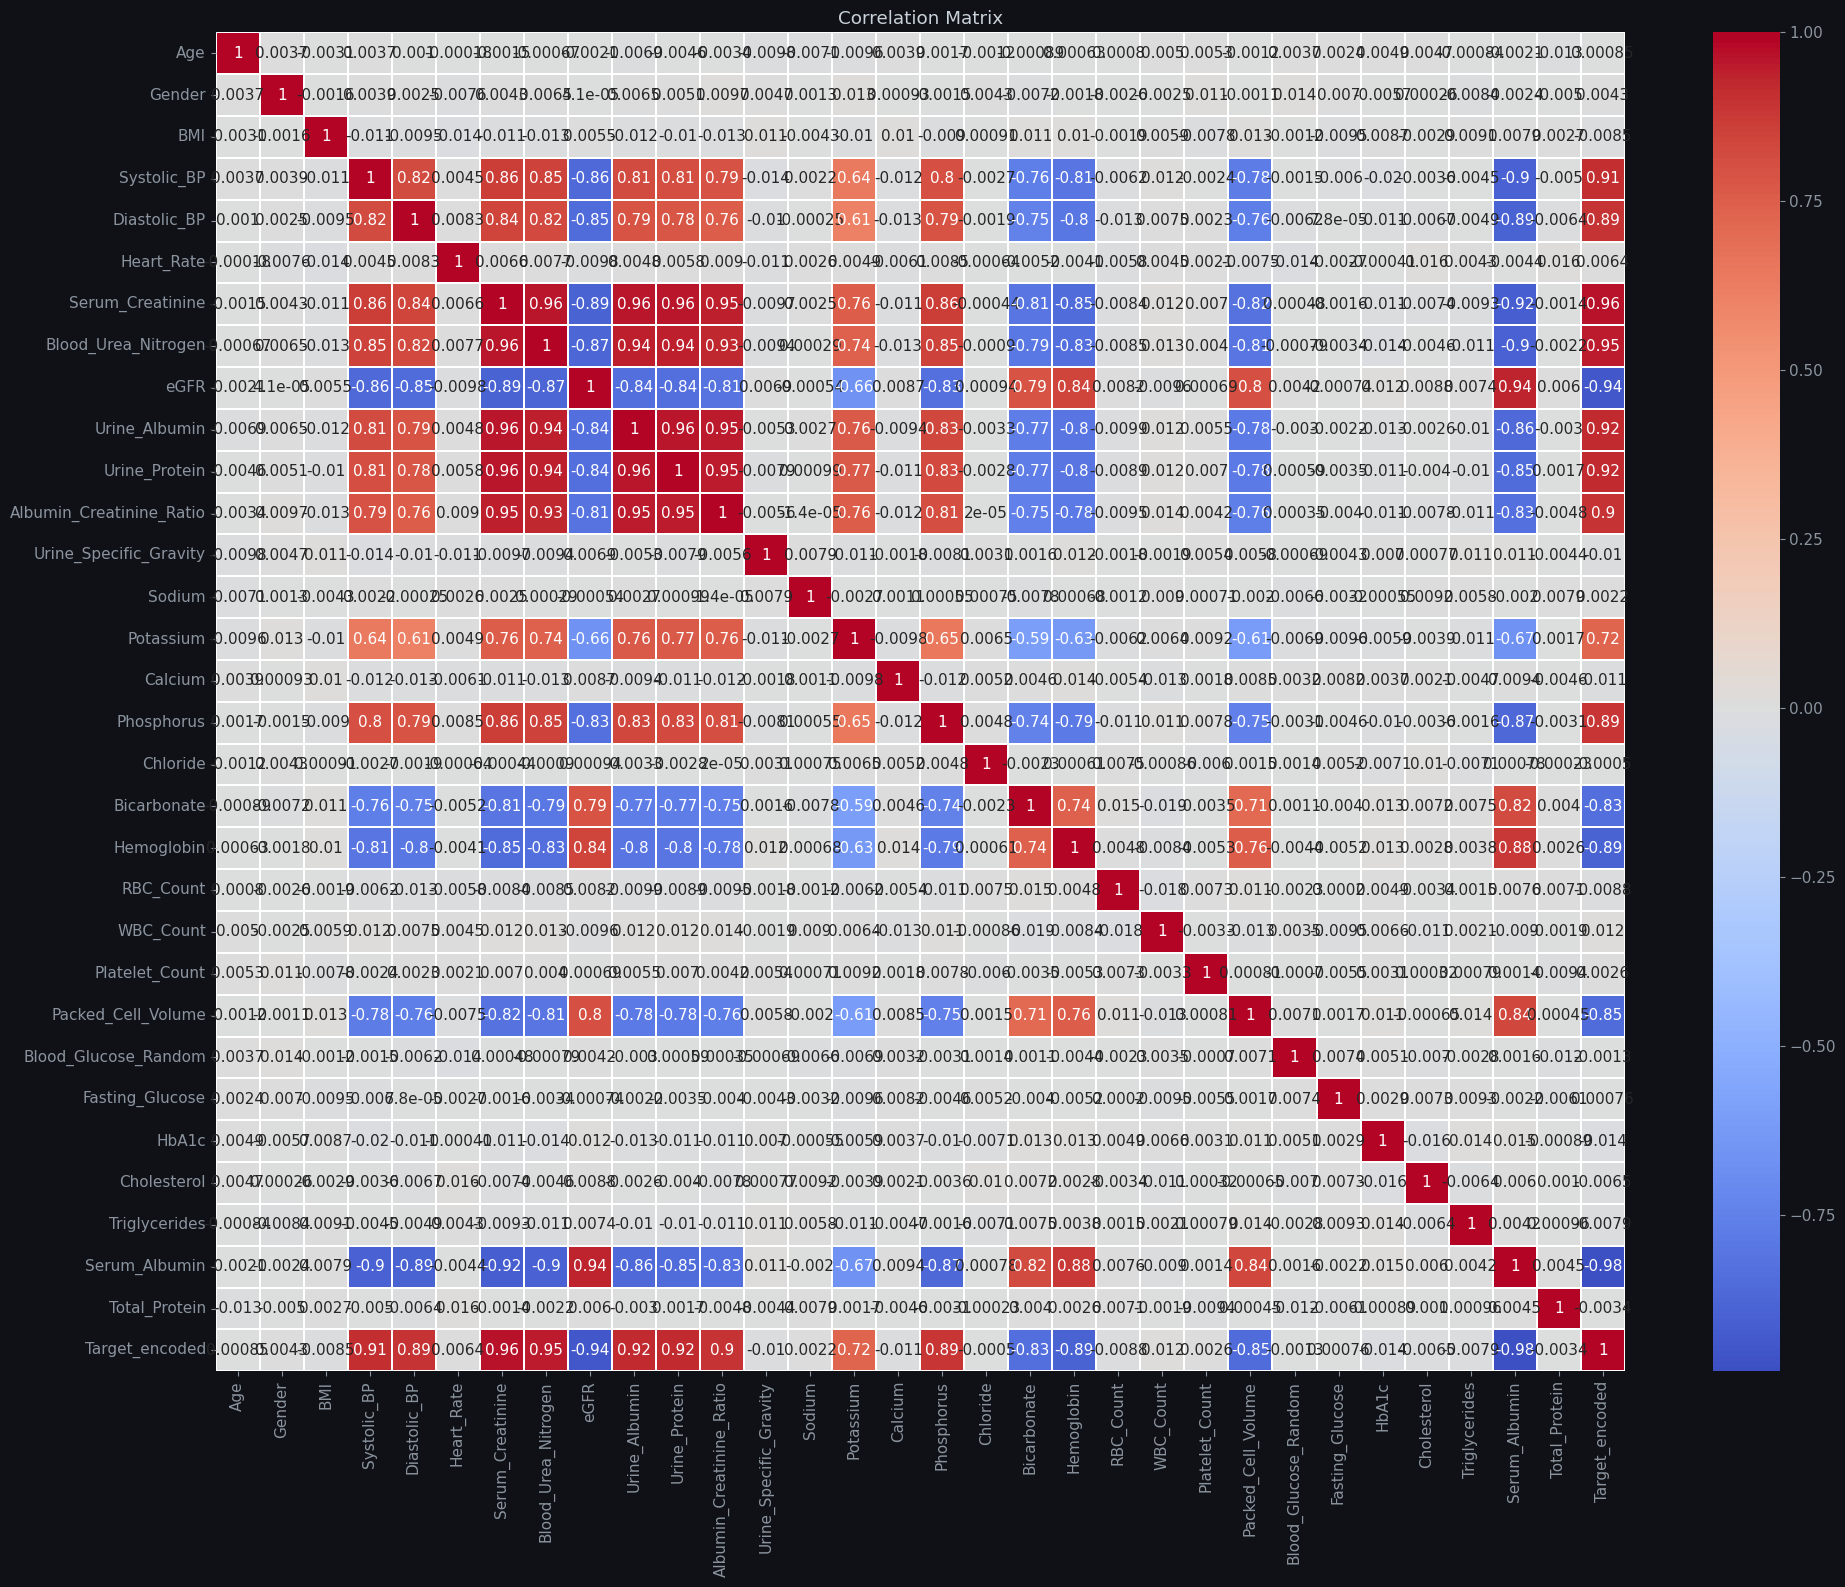

In [105]:
plt.figure(figsize=(20, 16))
sns.heatmap(df_train[numeric_cols.tolist() + ['Target_encoded']].corr(),
            annot=True, cmap='coolwarm', center=0, linewidths=0.3)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=100)
plt.show()